# Cookie Cats A/B Test: Gate 30 vs Gate 40

Cookie Cats is a mobile puzzle game where players progress through levels and occasionally hit a gate that asks them to wait or make an in-app purchase before continuing. This experiment tests whether moving the first gate from level 30 to level 40 improves player retention and engagement.

**Control (A)**: `gate_30`, the original gate placement  
**Treatment (B)**: `gate_40`, the proposed later gate placement

The business question is simple: should the product team move the gate later in the game, or keep the current experience?

## Notebook Setup

We import the project modules, analysis libraries, and plotting tools. The setup below detects whether the notebook is running from the project root or the `notebooks/` folder, then adds the project root to `sys.path`.

In [13]:
import math
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.diagnostics import NoveltyResult, check_srm
from src.reporting import generate_report
from src.statistical_tests import bayesian_ab_test, t_test_continuous, z_test_proportions

sns.set_theme(style="whitegrid", context="notebook")
DATA_URL = "https://raw.githubusercontent.com/yfsui/Mobile-Games-AB-Testing-Project/master/cookie_cats.csv"
CONTROL_VARIANT = "gate_30"
TREATMENT_VARIANT = "gate_40"
REPORT_PATH = PROJECT_ROOT / "reports" / "cookie_cats_report.html"
ALPHA = 0.05

# 1. Data Loading & EDA

First we load the public Cookie Cats experiment dataset and inspect the basics: row count, column types, missing values, and a few sample rows. Before running any test, this step helps confirm that the dataset has the expected structure.

In [14]:
df = pd.read_csv(DATA_URL)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print("\nDtypes:")
print(df.dtypes)
print("\nNull values:")
print(df.isna().sum())

df.head()

Shape: 90,189 rows x 5 columns

Dtypes:
userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object

Null values:
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


The engagement metric, `sum_gamerounds`, is expected to be heavily right-skewed: most players play a modest number of rounds, while a small number of highly engaged players play a very large number. We visualize both the raw distribution and a log-transformed version so the main mass of the data is easier to read.

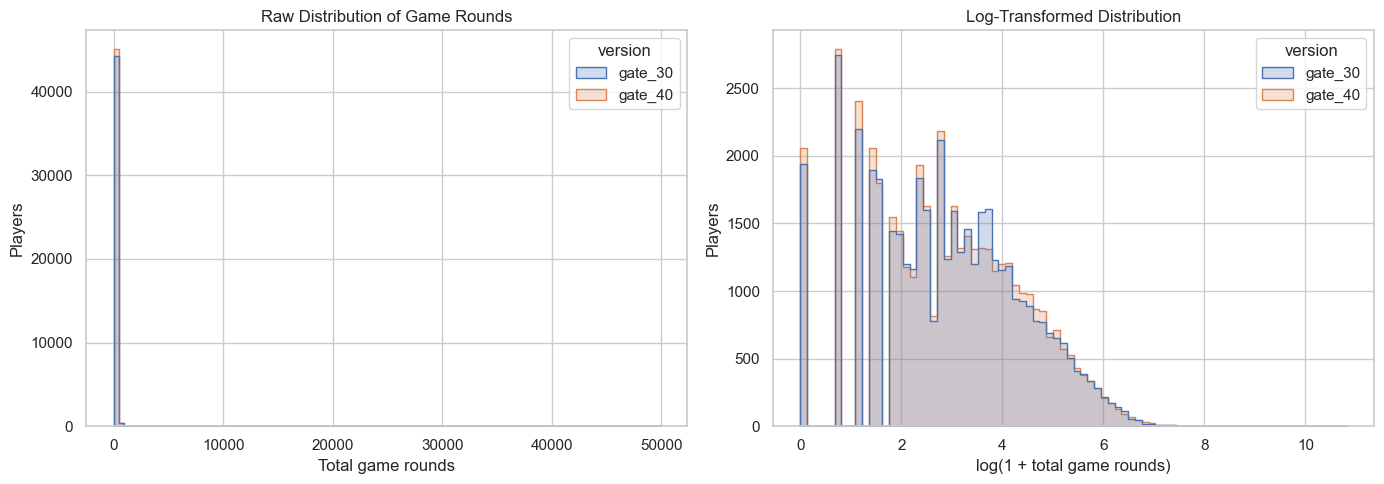

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="sum_gamerounds", hue="version", bins=100, ax=axes[0], element="step")
axes[0].set_title("Raw Distribution of Game Rounds")
axes[0].set_xlabel("Total game rounds")
axes[0].set_ylabel("Players")

sns.histplot(
    data=df.assign(log_gamerounds=lambda data: np.log1p(data["sum_gamerounds"])),
    x="log_gamerounds",
    hue="version",
    bins=80,
    ax=axes[1],
    element="step",
)
axes[1].set_title("Log-Transformed Distribution")
axes[1].set_xlabel("log(1 + total game rounds)")
axes[1].set_ylabel("Players")

plt.tight_layout()
plt.show()

Next we summarize the primary retention metrics by variant. `retention_1` captures short-term return behavior, while `retention_7` is a stronger signal of whether the change helps players build a habit.

In [16]:
summary = (
    df.groupby("version")
    .agg(
        users=("userid", "count"),
        avg_gamerounds=("sum_gamerounds", "mean"),
        median_gamerounds=("sum_gamerounds", "median"),
        retention_1=("retention_1", "mean"),
        retention_7=("retention_7", "mean"),
    )
    .loc[[CONTROL_VARIANT, TREATMENT_VARIANT]]
)

summary.style.format(
    {
        "users": "{:,}",
        "avg_gamerounds": "{:.2f}",
        "median_gamerounds": "{:.0f}",
        "retention_1": "{:.2%}",
        "retention_7": "{:.2%}",
    }
)

,users,avg_gamerounds,median_gamerounds,retention_1,retention_7
version,,,,,
gate_30,"44,700",52.46,17,44.82%,19.02%
gate_40,"45,489",51.30,16,44.23%,18.20%


A side-by-side retention chart makes the direction of the effect easier to see. This is not a statistical test yet; it is the descriptive view that tells us what the observed data looks like.

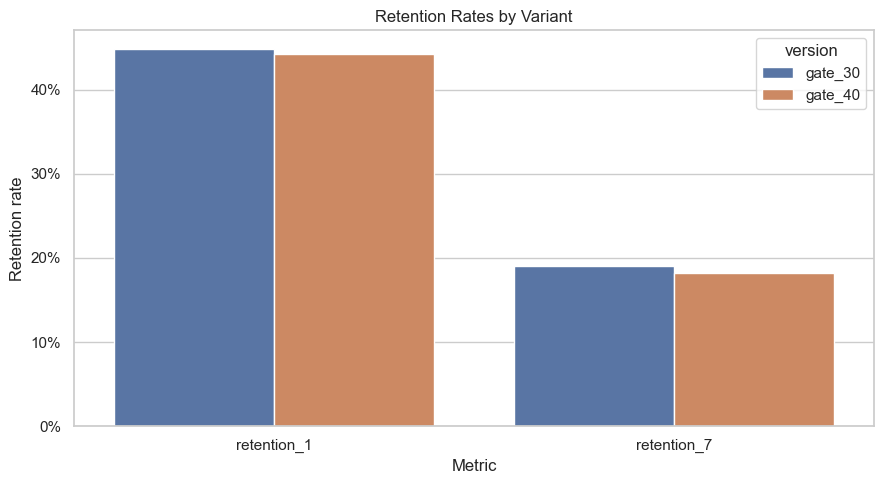

In [17]:
retention_long = (
    summary[["retention_1", "retention_7"]]
    .reset_index()
    .melt(id_vars="version", var_name="metric", value_name="retention_rate")
)

plt.figure(figsize=(9, 5))
sns.barplot(data=retention_long, x="metric", y="retention_rate", hue="version")
plt.title("Retention Rates by Variant")
plt.xlabel("Metric")
plt.ylabel("Retention rate")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
plt.tight_layout()
plt.show()

# 2. SRM Check

Sample Ratio Mismatch (SRM) checks whether users were split into variants as expected. We run it before interpreting results because a significant mismatch can indicate broken randomization, tracking loss, bot filtering differences, or assignment bugs. If SRM is present, the rest of the analysis may be biased even if the p-values look convincing.

In [18]:
group_sizes = df["version"].value_counts().loc[[CONTROL_VARIANT, TREATMENT_VARIANT]]
srm_result = check_srm(
    control_users=int(group_sizes.loc[CONTROL_VARIANT]),
    treatment_users=int(group_sizes.loc[TREATMENT_VARIANT]),
    expected_control_proportion=0.50,
)

print(f"{CONTROL_VARIANT} users: {group_sizes.loc[CONTROL_VARIANT]:,}")
print(f"{TREATMENT_VARIANT} users: {group_sizes.loc[TREATMENT_VARIANT]:,}")
print(f"Actual control split: {srm_result.actual_split:.4%}")
print(f"Chi-square statistic: {srm_result.chi2_stat:.4f}")
print(f"P-value: {srm_result.p_value:.6f}")
print(f"SRM detected: {srm_result.srm_detected}")

gate_30 users: 44,700
gate_40 users: 45,489
Actual control split: 49.5626%
Chi-square statistic: 6.9024
P-value: 0.008608
SRM detected: False


# 3. Retention 1 Analysis

One-day retention is a binary metric: each player either returned after one day or did not. We use the framework's two-proportion z-test to compare `gate_40` against `gate_30`, reporting relative lift, p-value, Cohen's h, and the confidence interval for the absolute difference in retention rates.

In [19]:
def binary_metric_test(data: pd.DataFrame, metric: str):
    control = data[data["version"] == CONTROL_VARIANT]
    treatment = data[data["version"] == TREATMENT_VARIANT]
    return z_test_proportions(
        control_converted=int(control[metric].sum()),
        control_total=len(control),
        treatment_converted=int(treatment[metric].sum()),
        treatment_total=len(treatment),
        alpha=ALPHA,
    )

retention_1_result = binary_metric_test(df, "retention_1")

print("RETENTION_1 RESULTS")
print("=" * 50)
print(f"Control rate ({CONTROL_VARIANT}):   {retention_1_result.control_rate:.4%}")
print(f"Treatment rate ({TREATMENT_VARIANT}): {retention_1_result.treatment_rate:.4%}")
print(f"Relative lift:                  {retention_1_result.lift:.2%}")
print(f"Cohen's h:                      {retention_1_result.cohens_h:.4f}")
print(f"Z-statistic:                    {retention_1_result.z_stat:.4f}")
print(f"P-value:                        {retention_1_result.p_value:.6f}")
print(
    "95% CI absolute difference:   "
    f"[{retention_1_result.ci_lower:.4%}, {retention_1_result.ci_upper:.4%}]"
)
print(f"Significant at alpha={ALPHA}:    {retention_1_result.significant}")

RETENTION_1 RESULTS
Control rate (gate_30):   44.8188%
Treatment rate (gate_40): 44.2283%
Relative lift:                  -1.32%
Cohen's h:                      -0.0119
Z-statistic:                    -1.7841
P-value:                        0.074410
95% CI absolute difference:   [-1.2392%, 0.0582%]
Significant at alpha=0.05:    False


**Interpretation:** `retention_1` tells us whether the new gate placement changes immediate return behavior. If the confidence interval includes zero or the p-value is above 0.05, we should avoid treating the observed lift as reliable evidence of a short-term improvement.

# 4. Retention 7 Analysis

Seven-day retention is more important than one-day retention for this product decision because it better reflects habit formation and medium-term player value. A change that creates curiosity on day one but reduces day-seven retention can still be harmful for the business.

In [20]:
retention_7_result = binary_metric_test(df, "retention_7")

print("RETENTION_7 RESULTS")
print("=" * 50)
print(f"Control rate ({CONTROL_VARIANT}):   {retention_7_result.control_rate:.4%}")
print(f"Treatment rate ({TREATMENT_VARIANT}): {retention_7_result.treatment_rate:.4%}")
print(f"Relative lift:                  {retention_7_result.lift:.2%}")
print(f"Cohen's h:                      {retention_7_result.cohens_h:.4f}")
print(f"Z-statistic:                    {retention_7_result.z_stat:.4f}")
print(f"P-value:                        {retention_7_result.p_value:.6f}")
print(
    "95% CI absolute difference:   "
    f"[{retention_7_result.ci_lower:.4%}, {retention_7_result.ci_upper:.4%}]"
)
print(f"Significant at alpha={ALPHA}:    {retention_7_result.significant}")

RETENTION_7 RESULTS
Control rate (gate_30):   19.0201%
Treatment rate (gate_40): 18.2000%
Relative lift:                  -4.31%
Cohen's h:                      -0.0211
Z-statistic:                    -3.1644
P-value:                        0.001554
95% CI absolute difference:   [-1.3282%, -0.3121%]
Significant at alpha=0.05:    True


**Interpretation:** This is the key retention readout. If `gate_40` lowers seven-day retention, even slightly, the product team should be careful: the later gate may reduce commitment or change the pacing in a way that hurts longer-term engagement.

# 5. Engagement Analysis

`sum_gamerounds` is a continuous engagement metric, but it is zero-inflated and heavily right-skewed. That violates the spirit of a simple mean-based t-test because a few extreme players can dominate the average. For this reason, we use the Mann-Whitney U option in `t_test_continuous`, which compares distributions non-parametrically and is more robust for skewed data.

In [21]:
control_rounds = df.loc[df["version"] == CONTROL_VARIANT, "sum_gamerounds"].to_numpy()
treatment_rounds = df.loc[df["version"] == TREATMENT_VARIANT, "sum_gamerounds"].to_numpy()

engagement_result = t_test_continuous(
    control_values=control_rounds,
    treatment_values=treatment_rounds,
    alpha=ALPHA,
    use_mann_whitney=True,
)

print("ENGAGEMENT RESULTS (Mann-Whitney U)")
print("=" * 50)
print(f"Control mean rounds:     {engagement_result.control_mean:.2f}")
print(f"Treatment mean rounds:   {engagement_result.treatment_mean:.2f}")
print(f"Relative lift:           {engagement_result.lift:.2%}")
print(f"Test statistic:          {engagement_result.t_stat:.4f}")
print(f"P-value:                 {engagement_result.p_value:.6f}")
print(f"Significant:             {engagement_result.significant}")
print(f"Test type:               {engagement_result.test_type}")

ENGAGEMENT RESULTS (Mann-Whitney U)
Control mean rounds:     52.46
Treatment mean rounds:   51.30
Relative lift:           -2.21%
Test statistic:          1009027049.5000
P-value:                 0.050209
Significant:             False
Test type:               mann_whitney


The Mann-Whitney result answers whether the engagement distributions differ, not whether the arithmetic means differ. That distinction matters here because the product impact should not be inferred from the mean alone when the metric has extreme outliers.

# 6. HTML Report

The framework's report generator expects a standard A/B testing schema with `variant`, `converted`, `revenue`, and `timestamp`. The Cookie Cats dataset has no timestamp, so for the report only we create a deterministic pseudo-date column. The report uses seven-day retention as the binary conversion metric because it is the more business-relevant outcome.

In [22]:
bayes_result = bayesian_ab_test(
    control_converted=int(df.loc[df["version"] == CONTROL_VARIANT, "retention_7"].sum()),
    control_total=int((df["version"] == CONTROL_VARIANT).sum()),
    treatment_converted=int(df.loc[df["version"] == TREATMENT_VARIANT, "retention_7"].sum()),
    treatment_total=int((df["version"] == TREATMENT_VARIANT).sum()),
    n_samples=100_000,
    seed=42,
)

report_df = pd.DataFrame(
    {
        "user_id": df["userid"].astype(int),
        "variant": df["version"].map({CONTROL_VARIANT: "control", TREATMENT_VARIANT: "treatment"}),
        "converted": df["retention_7"].astype(int),
        "revenue": df["sum_gamerounds"].astype(float),
        "timestamp": pd.Timestamp("2017-01-01") + pd.to_timedelta(df.index % 30, unit="D"),
    }
)
report_df["day_of_week"] = report_df["timestamp"].dt.day_name()

# The source data has no true time series, so novelty is not assessed in this real dataset report.
novelty_result = NoveltyResult(
    kendall_tau=0.0,
    p_value=1.0,
    novelty_detected=False,
)

report_path = generate_report(
    df=report_df,
    freq_result=retention_7_result,
    bayesian_result=bayes_result,
    srm_result=srm_result,
    novelty_result=novelty_result,
    output_path=str(REPORT_PATH),
)

print(f"HTML report saved to: {report_path}")
print(f"P(treatment beats control) on retention_7: {bayes_result.prob_treatment_wins:.2%}")

HTML report saved to: c:\Users\Aditya\OneDrive\文件\Desktop\Projects\ab_testing_framework\reports\cookie_cats_report.html
P(treatment beats control) on retention_7: 0.10%


# 7. Business Decision

`gate_40` reduced 7-day retention by **4.31%** relative to `gate_30` (**p=0.0016**, 95% CI **[-1.33%, -0.31%]**). The Bayesian posterior gives only a **0.10% probability** that `gate_40` beats `gate_30`. Engagement does not rescue the treatment: the Mann-Whitney test on `sum_gamerounds` is **p=0.050**, not significant, so there is no reliable upside in rounds played.

The likely product mechanism is the **endowed progress effect**. Players approaching `gate_30` have already made visible progress and are close enough to the gate for that proximity to become motivating. The gate is not simply friction; it acts as a commitment marker. Moving the gate to `gate_40` removes that motivational friction too early, weakening the commitment loop that drives players to return over the next week.

The engagement result makes the decision clearer. `gate_40` offers no compensating upside in rounds played. A product team might accept lower retention if the treatment produced meaningfully higher engagement, but it did not. That makes the case for `gate_40` weaker on all fronts: lower 7-day retention, near-zero Bayesian probability of winning, and no statistically reliable engagement gain.

Caveats: the dataset has no timestamp data, so novelty effect could not be assessed on real data. It also has no segmentation by acquisition channel, device, geography, or monetization tier, so segment-level effects may differ. Revenue impact is unknown; retention and engagement are proxies for business value.

**HOLD. Keep `gate_30`. The data consistently favours the control on the metric that matters most.**
